In [1]:
# Installation des dépendances — à exécuter une seule fois
import sys
!{sys.executable} -m pip install pillow numpy pandas matplotlib scikit-learn --quiet
print("Installation terminée.")

Installation terminée.


# Exploration du dataset BrainScanAI — Phase 1

Premier passage sur les données transmises pour le projet BrainScanAI. L'objectif ici est: comprendre comment le dataset est organisé, vérifier la cohérence des images (résolution, canaux, format) et repérer en amont tout problème de qualité qui pourrait impacter les étapes suivantes.

In [2]:
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"


## 1. Décompression et inventaire

In [3]:
ZIP_PATH = Path("mri_dataset_brain_cancer_oc.zip")
DATA_ROOT = Path("mri_dataset_brain_cancer_oc")

if not DATA_ROOT.exists():
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(".")

records = []
for split_dir, label in [
    (DATA_ROOT / "avec_labels" / "normal", "normal"),
    (DATA_ROOT / "avec_labels" / "cancer", "cancer"),
    (DATA_ROOT / "sans_label", None),
]:
    pool = "avec_labels" if label is not None else "sans_label"
    for fp in sorted(split_dir.glob("*.jpg")):
        records.append({
            "filepath": str(fp),
            "filename": fp.name,
            "pool": pool,
            "label": label,
            "filesize_bytes": fp.stat().st_size,
        })

df = pd.DataFrame(records)
print(f"{len(df)} images recensées au total.")
df.groupby(["pool", "label"], dropna=False).size()


1506 images recensées au total.


pool         label 
avec_labels  cancer      50
             normal      50
sans_label   NaN       1406
dtype: int64

In [4]:
doc_files = list(DATA_ROOT.glob("*.txt"))
print(f"Fichier de documentation trouvé : {doc_files[0].name}\n")
print(doc_files[0].read_text(encoding="utf-8"))


Fichier de documentation trouvé : Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt

Description

Ce jeu de données comprend un total de 1500 images :

    1400 images non étiquetées

    100 images étiquetées

Les images étiquetées sont réparties en deux catégories :

    Normal : Images de cerveaux sains.

    Cancer : Images de cerveaux présentant des signes de tumeurs.

Caractéristiques des Images

Toutes les images ont été redimensionnées à une taille standardisée de 512×512 pixels. Cette standardisation assure leur compatibilité avec divers pipelines de traitement d'images et d'apprentissage automatique. Elles sont enregistrées au format d'image courant JPEG (.jpg).
Applications Potentielles

Ce jeu de données peut être exploité pour un large éventail d'applications, notamment :

    🤖 L'entraînement et l'évaluation de divers modèles d'apprentissage profond (par exemple, DenseNet201, YOLOv8x/s, CNN, ResNet50v2, VGG-16, MobileNetV2).

    🔬 Le développement d'alg

## 2. Résolution, canaux de couleur et intégrité des fichiers

Je passe maintenant chaque image en revue avec Pillow pour vérifier qu'elles ont toutes la résolution annoncée, le même mode couleur, et qu'aucune n'est corrompue.

In [5]:
widths, heights, modes, formats, open_errors = [], [], [], [], []

for fp in df["filepath"]:
    try:
        with Image.open(fp) as im:
            im.load()
            widths.append(im.size[0])
            heights.append(im.size[1])
            modes.append(im.mode)
            formats.append(im.format)
            open_errors.append(None)
    except Exception as e:
        widths.append(None); heights.append(None); modes.append(None); formats.append(None)
        open_errors.append(str(e))

df["width"] = widths
df["height"] = heights
df["mode"] = modes
df["format"] = formats
df["open_error"] = open_errors

print("Images illisibles :", df["open_error"].notna().sum())
print("\nRésolutions rencontrées :")
print(df.groupby(["width", "height"]).size().to_string())
print("\nModes couleur :", dict(df["mode"].value_counts()))
print("Formats :", dict(df["format"].value_counts()))


Images illisibles : 0

Résolutions rencontrées :
width  height
512    512       1506

Modes couleur : {'RGB': np.int64(1506)}
Formats : {'JPEG': np.int64(1506)}


Aucune image corrompue, et tout est parfaitement homogène : 512×512, JPEG, mode RGB pour les 1506 fichiers. Ça correspond à ce qu'annonce la doc. Je vérifie si les trois canaux sont réellement redondants ou s'il y a une vraie information couleur encodée dedans.

In [6]:
sample_channels = df.sample(n=80, random_state=42)
identical = 0
max_diffs = []
for fp in sample_channels["filepath"]:
    with Image.open(fp) as im:
        arr = np.array(im.convert("RGB"))
    diff = max(
        np.abs(arr[:, :, 0].astype(int) - arr[:, :, 1].astype(int)).max(),
        np.abs(arr[:, :, 0].astype(int) - arr[:, :, 2].astype(int)).max(),
    )
    max_diffs.append(diff)
    if diff == 0:
        identical += 1

print(f"{identical}/{len(sample_channels)} images ont des canaux R=G=B strictement identiques.")
print(f"Écart maximum observé entre canaux sur l'échantillon : {max(max_diffs)} (sur 255).")


79/80 images ont des canaux R=G=B strictement identiques.
Écart maximum observé entre canaux sur l'échantillon : 12 (sur 255).


Ce sont donc bien des images en niveaux de gris, simplement encodées sur 3 canaux. 

## 3. Doublons et fuite potentielle entre les deux pools

Avant d'aller plus loin, je vérifie qu'il n'y a pas de doublons exacts entre `avec_labels` et `sans_label`. C'est un point sur lequel la consigne insiste : les deux jeux ne doivent jamais être mélangés. Si la même image se retrouve dans les deux pools, j'ai un problème de fuite de données dès cette étape.

In [7]:
def md5_of(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["md5"] = df["filepath"].apply(md5_of)

n_unique = df["md5"].nunique()
print(f"{len(df) - n_unique} fichiers dupliqués (même contenu binaire) sur {len(df)} images, {n_unique} contenus uniques.")

dupe_hashes = df["md5"].value_counts()
dupe_hashes = dupe_hashes[dupe_hashes > 1]

cross_pool_hashes, contradictory_label_hashes = [], []
for h, group in df[df["md5"].isin(dupe_hashes.index)].groupby("md5"):
    pools = set(group["pool"])
    labels = set(group["label"].dropna())
    if len(pools) > 1:
        cross_pool_hashes.append(h)
    if len(labels) > 1:
        contradictory_label_hashes.append(h)

n_avec_labels_touched = df[(df["pool"] == "avec_labels") & (df["md5"].isin(cross_pool_hashes))].shape[0]
n_sans_label_touched = df[(df["pool"] == "sans_label") & (df["md5"].isin(cross_pool_hashes))].shape[0]

print(f"\nGroupes de doublons à cheval sur avec_labels ET sans_label : {len(cross_pool_hashes)}")
print(f"  -> {n_avec_labels_touched} images du jeu fortement labellisé concernées (sur 100)")
print(f"  -> {n_sans_label_touched} images du pool sans_label concernées (sur {len(df[df.pool=='sans_label'])})")
print(f"Doublons avec labels contradictoires (même image taguée normal ET cancer) : {len(contradictory_label_hashes)}")

df["leak_cross_pool"] = df["md5"].isin(cross_pool_hashes)


96 fichiers dupliqués (même contenu binaire) sur 1506 images, 1410 contenus uniques.

Groupes de doublons à cheval sur avec_labels ET sans_label : 31
  -> 32 images du jeu fortement labellisé concernées (sur 100)
  -> 32 images du pool sans_label concernées (sur 1406)
Doublons avec labels contradictoires (même image taguée normal ET cancer) : 0


**32 images du jeu `avec_labels` (presque un tiers — 23 « normal » et 8 « cancer ») ont un double byte-à-byte identique dans le pool `sans_label`.** Aucun label contradictoire en revanche : une même image n'est jamais taguée à la fois normal et cancer, donc le jeu fortement labellisé est cohérent en interne.

Je retire ces doublons du pool `sans_label` (je garde la version `avec_labels`, qui a l'avantage d'avoir un vrai label) avant toute extraction de features destinée au clustering.

In [8]:
df["exclude_recommended"] = (df["pool"] == "sans_label") & (df["leak_cross_pool"])
print(f"Images marquées à exclure du pool sans_label avant la suite : {df['exclude_recommended'].sum()}")

df.to_csv("manifest_dataset.csv", index=False)
print("Manifeste complet sauvegardé -> manifest_dataset.csv")


Images marquées à exclure du pool sans_label avant la suite : 32
Manifeste complet sauvegardé -> manifest_dataset.csv


## 4. Coup d'œil visuel

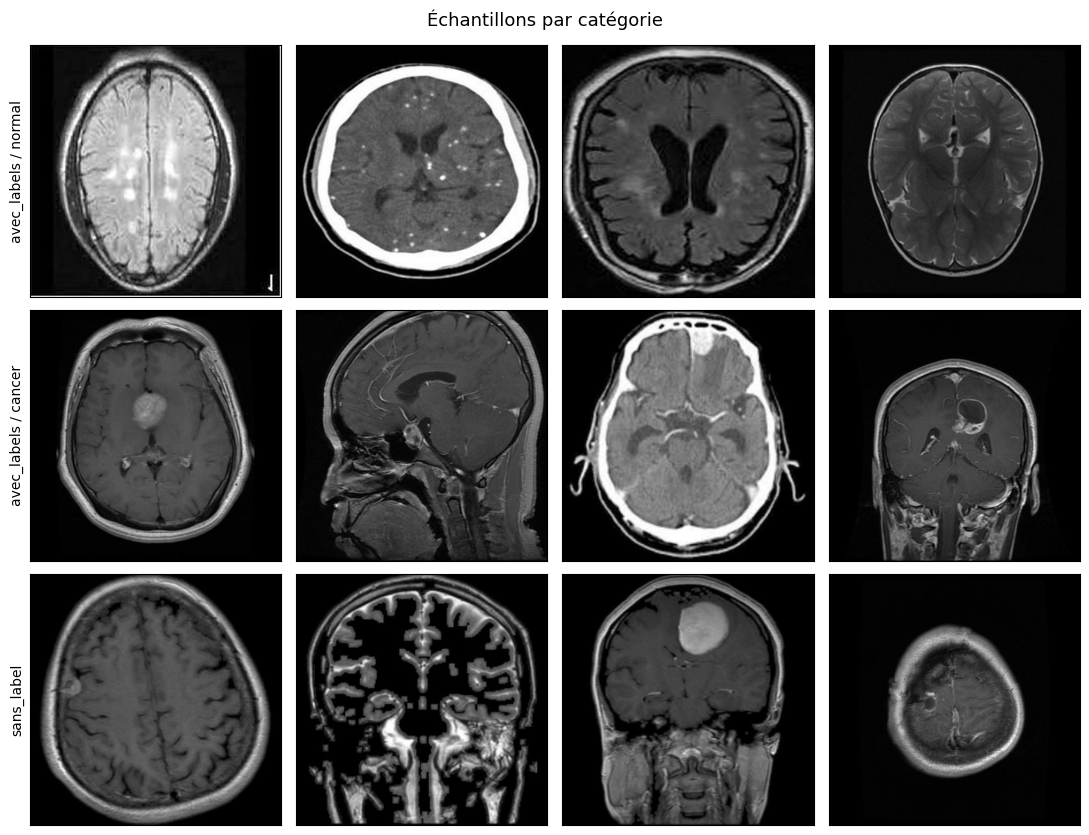

In [9]:
normal_examples = df[df["label"] == "normal"].sample(4, random_state=7)["filepath"].tolist()
cancer_examples = df[df["label"] == "cancer"].sample(4, random_state=7)["filepath"].tolist()
unlabeled_examples = df[df["pool"] == "sans_label"].sample(4, random_state=7)["filepath"].tolist()

fig, axes = plt.subplots(3, 4, figsize=(11, 8.5))
for row, (row_title, paths) in enumerate([
    ("avec_labels / normal", normal_examples),
    ("avec_labels / cancer", cancer_examples),
    ("sans_label", unlabeled_examples),
]):
    for col, fp in enumerate(paths):
        ax = axes[row, col]
        with Image.open(fp) as im:
            ax.imshow(im, cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(row_title, fontsize=10)
fig.suptitle("Échantillons par catégorie", fontsize=13)
plt.tight_layout()
plt.show()


Ces images ne sont pas homogènes en termes de plan de coupe. Je vois de l'axial, du sagittal et du coronal mélangés dans les trois catégories, parfois pour une même classe. Pour un futur entraînement, ça veut dire que le modèle devra apprendre à reconnaître une tumeur indépendamment du plan de coupe, ce qui est nettement plus dur qu'avec un jeu homogène.

## 5. Intensité des pixels par classe

Avant de partir sur des features profondes, un sanity check simple : est-ce que les deux classes se distinguent déjà sur un indicateur basique comme l'intensité moyenne des pixels ?

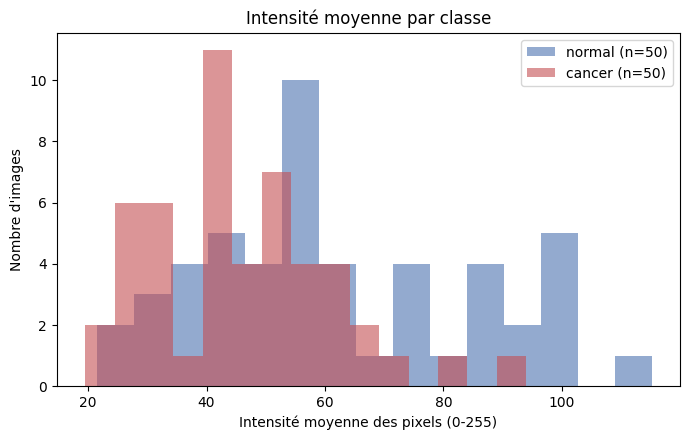

Moyenne normal : 61.8  |  Moyenne cancer : 46.0


In [10]:
def mean_intensity(fp):
    with Image.open(fp) as im:
        return np.array(im.convert("L"), dtype=np.float32).mean()

intens_normal = df[df["label"] == "normal"]["filepath"].apply(mean_intensity)
intens_cancer = df[df["label"] == "cancer"]["filepath"].apply(mean_intensity)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(intens_normal, bins=15, alpha=0.6, label=f"normal (n={len(intens_normal)})", color="#4C72B0")
ax.hist(intens_cancer, bins=15, alpha=0.6, label=f"cancer (n={len(intens_cancer)})", color="#C44E52")
ax.set_xlabel("Intensité moyenne des pixels (0-255)")
ax.set_ylabel("Nombre d'images")
ax.set_title("Intensité moyenne par classe")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Moyenne normal : {intens_normal.mean():.1f}  |  Moyenne cancer : {intens_cancer.mean():.1f}")


Les deux distributions se chevauchent largement, mais la classe cancer penche vers des images plus sombres en moyenne.

## 6. Répartition globale du dataset

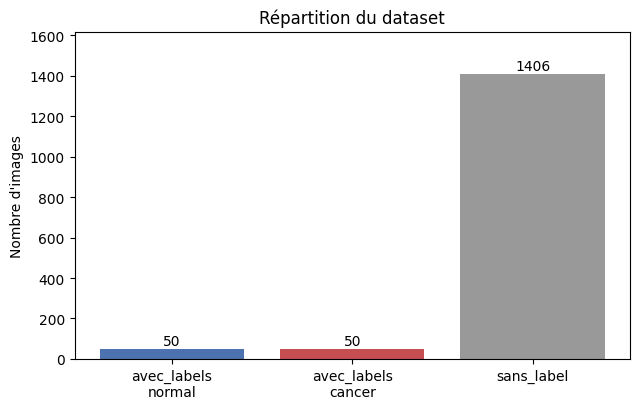

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
pool_label_counts = [
    len(df[(df["pool"] == "avec_labels") & (df["label"] == "normal")]),
    len(df[(df["pool"] == "avec_labels") & (df["label"] == "cancer")]),
    len(df[df["pool"] == "sans_label"]),
]
bar_labels = ["avec_labels\nnormal", "avec_labels\ncancer", "sans_label"]
bars = ax.bar(bar_labels, pool_label_counts, color=["#4C72B0", "#C44E52", "#999999"])
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 20, str(int(b.get_height())), ha="center")
ax.set_ylabel("Nombre d'images")
ax.set_title("Répartition du dataset")
ax.set_ylim(0, max(pool_label_counts) * 1.15)
plt.tight_layout()
plt.show()


## Ce que je retiens de cette première exploration

Le dataset est propre techniquement : résolution, format et mode couleur uniformes, aucun fichier corrompu. Mais il y a deux problèmes de fond à traiter avant l'extraction de features :

1. **Fuite de données** entre `avec_labels` et `sans_label` — 32 % du jeu fortement labellisé est dupliqué dans le pool faible. Les images concernées sont identifiées et marquées dans `manifest_dataset.csv` (colonne `exclude_recommended`), à exclure du pool `sans_label` dès la prochaine étape.
2. **Hétérogénéité des images** — plans de coupe mélangés (axial/sagittal/coronal).